In [1]:

# imports
import os
import sys
import types
import json
import base64

# figure size/format
fig_width = 7
fig_height = 5
fig_format = 'retina'
fig_dpi = 96
interactivity = ''
is_shiny = False
is_dashboard = False
plotly_connected = True

# matplotlib defaults / format
try:
  import matplotlib.pyplot as plt
  plt.rcParams['figure.figsize'] = (fig_width, fig_height)
  plt.rcParams['figure.dpi'] = fig_dpi
  plt.rcParams['savefig.dpi'] = "figure"

  # IPython 7.14 deprecated set_matplotlib_formats from IPython
  try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
  except ImportError:
    # Fall back to deprecated location for older IPython versions
    from IPython.display import set_matplotlib_formats
    
  set_matplotlib_formats(fig_format)
except Exception:
  pass

# plotly use connected mode
try:
  import plotly.io as pio
  if plotly_connected:
    pio.renderers.default = "notebook_connected"
  else:
    pio.renderers.default = "notebook"
  for template in pio.templates.keys():
    pio.templates[template].layout.margin = dict(t=30,r=0,b=0,l=0)
except Exception:
  pass

# disable itables paging for dashboards
if is_dashboard:
  try:
    from itables import options
    options.dom = 'fiBrtlp'
    options.maxBytes = 1024 * 1024
    options.language = dict(info = "Showing _TOTAL_ entries")
    options.classes = "display nowrap compact"
    options.paging = False
    options.searching = True
    options.ordering = True
    options.info = True
    options.lengthChange = False
    options.autoWidth = False
    options.responsive = True
    options.keys = True
    options.buttons = []
  except Exception:
    pass
  
  try:
    import altair as alt
    # By default, dashboards will have container sized
    # vega visualizations which allows them to flow reasonably
    theme_sentinel = '_quarto-dashboard-internal'
    def make_theme(name):
        nonTheme = alt.themes._plugins[name]    
        def patch_theme(*args, **kwargs):
            existingTheme = nonTheme()
            if 'height' not in existingTheme:
              existingTheme['height'] = 'container'
            if 'width' not in existingTheme:
              existingTheme['width'] = 'container'

            if 'config' not in existingTheme:
              existingTheme['config'] = dict()
            
            # Configure the default font sizes
            title_font_size = 15
            header_font_size = 13
            axis_font_size = 12
            legend_font_size = 12
            mark_font_size = 12
            tooltip = False

            config = existingTheme['config']

            # The Axis
            if 'axis' not in config:
              config['axis'] = dict()
            axis = config['axis']
            if 'labelFontSize' not in axis:
              axis['labelFontSize'] = axis_font_size
            if 'titleFontSize' not in axis:
              axis['titleFontSize'] = axis_font_size  

            # The legend
            if 'legend' not in config:
              config['legend'] = dict()
            legend = config['legend']
            if 'labelFontSize' not in legend:
              legend['labelFontSize'] = legend_font_size
            if 'titleFontSize' not in legend:
              legend['titleFontSize'] = legend_font_size  

            # The header
            if 'header' not in config:
              config['header'] = dict()
            header = config['header']
            if 'labelFontSize' not in header:
              header['labelFontSize'] = header_font_size
            if 'titleFontSize' not in header:
              header['titleFontSize'] = header_font_size    

            # Title
            if 'title' not in config:
              config['title'] = dict()
            title = config['title']
            if 'fontSize' not in title:
              title['fontSize'] = title_font_size

            # Marks
            if 'mark' not in config:
              config['mark'] = dict()
            mark = config['mark']
            if 'fontSize' not in mark:
              mark['fontSize'] = mark_font_size

            # Mark tooltips
            if tooltip and 'tooltip' not in mark:
              mark['tooltip'] = dict(content="encoding")

            return existingTheme
            
        return patch_theme

    # We can only do this once per session
    if theme_sentinel not in alt.themes.names():
      for name in alt.themes.names():
        alt.themes.register(name, make_theme(name))
      
      # register a sentinel theme so we only do this once
      alt.themes.register(theme_sentinel, make_theme('default'))
      alt.themes.enable('default')

  except Exception:
    pass

# enable pandas latex repr when targeting pdfs
try:
  import pandas as pd
  if fig_format == 'pdf':
    pd.set_option('display.latex.repr', True)
except Exception:
  pass

# interactivity
if interactivity:
  from IPython.core.interactiveshell import InteractiveShell
  InteractiveShell.ast_node_interactivity = interactivity

# NOTE: the kernel_deps code is repeated in the cleanup.py file
# (we can't easily share this code b/c of the way it is run).
# If you edit this code also edit the same code in cleanup.py!

# output kernel dependencies
kernel_deps = dict()
for module in list(sys.modules.values()):
  # Some modules play games with sys.modules (e.g. email/__init__.py
  # in the standard library), and occasionally this can cause strange
  # failures in getattr.  Just ignore anything that's not an ordinary
  # module.
  if not isinstance(module, types.ModuleType):
    continue
  path = getattr(module, "__file__", None)
  if not path:
    continue
  if path.endswith(".pyc") or path.endswith(".pyo"):
    path = path[:-1]
  if not os.path.exists(path):
    continue
  kernel_deps[path] = os.stat(path).st_mtime
print(json.dumps(kernel_deps))

# set run_path if requested
run_path = 'L1VzZXJzL2FsYWwvRGVza3RvcC9jb2RlL2NyYWJieW1ldHJpY3MvZG9jcy9hYmxhdGlvbnM='
if run_path:
  # hex-decode the path
  run_path = base64.b64decode(run_path.encode("utf-8")).decode("utf-8")
  os.chdir(run_path)

# reset state
%reset

# shiny
# Checking for shiny by using False directly because we're after the %reset. We don't want
# to set a variable that stays in global scope.
if False:
  try:
    import htmltools as _htmltools
    import ast as _ast

    _htmltools.html_dependency_render_mode = "json"

    # This decorator will be added to all function definitions
    def _display_if_has_repr_html(x):
      try:
        # IPython 7.14 preferred import
        from IPython.display import display, HTML
      except:
        from IPython.core.display import display, HTML

      if hasattr(x, '_repr_html_'):
        display(HTML(x._repr_html_()))
      return x

    # ideally we would undo the call to ast_transformers.append
    # at the end of this block whenver an error occurs, we do 
    # this for now as it will only be a problem if the user 
    # switches from shiny to not-shiny mode (and even then likely
    # won't matter)
    import builtins
    builtins._display_if_has_repr_html = _display_if_has_repr_html

    class _FunctionDefReprHtml(_ast.NodeTransformer):
      def visit_FunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

      def visit_AsyncFunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

    ip = get_ipython()
    ip.ast_transformers.append(_FunctionDefReprHtml())

  except:
    pass

def ojs_define(**kwargs):
  import json
  try:
    # IPython 7.14 preferred import
    from IPython.display import display, HTML
  except:
    from IPython.core.display import display, HTML

  # do some minor magic for convenience when handling pandas
  # dataframes
  def convert(v):
    try:
      import pandas as pd
    except ModuleNotFoundError: # don't do the magic when pandas is not available
      return v
    if type(v) == pd.Series:
      v = pd.DataFrame(v)
    if type(v) == pd.DataFrame:
      j = json.loads(v.T.to_json(orient='split'))
      return dict((k,v) for (k,v) in zip(j["index"], j["data"]))
    else:
      return v

  v = dict(contents=list(dict(name=key, value=convert(value)) for (key, value) in kwargs.items()))
  display(HTML('<script type="ojs-define">' + json.dumps(v) + '</script>'), metadata=dict(ojs_define = True))
globals()["ojs_define"] = ojs_define
globals()["__spec__"] = None

{"/Users/alal/.local/share/uv/python/cpython-3.12.9-macos-aarch64-none/lib/python3.12/importlib/_bootstrap.py": 1743382022.7735002, "/Users/alal/.local/share/uv/python/cpython-3.12.9-macos-aarch64-none/lib/python3.12/importlib/_bootstrap_external.py": 1743382022.7737157, "/Users/alal/.local/share/uv/python/cpython-3.12.9-macos-aarch64-none/lib/python3.12/zipimport.py": 1743382022.8471594, "/Users/alal/.local/share/uv/python/cpython-3.12.9-macos-aarch64-none/lib/python3.12/codecs.py": 1743382022.716922, "/Users/alal/.local/share/uv/python/cpython-3.12.9-macos-aarch64-none/lib/python3.12/encodings/aliases.py": 1743382022.7266889, "/Users/alal/.local/share/uv/python/cpython-3.12.9-macos-aarch64-none/lib/python3.12/encodings/__init__.py": 1743382022.7262201, "/Users/alal/.local/share/uv/python/cpython-3.12.9-macos-aarch64-none/lib/python3.12/encodings/utf_8.py": 1743382022.7358487, "/Users/alal/.local/share/uv/python/cpython-3.12.9-macos-aarch64-none/lib/python3.12/abc.py": 1743382022.7091

In [2]:
from html import escape

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import HTML, display

import crabbymetrics as cm

np.set_printoptions(precision=4, suppress=True)


def html_table(headers, rows):
    parts = [
        "<table>",
        "<thead>",
        "<tr>",
        *[f"<th>{escape(str(header))}</th>" for header in headers],
        "</tr>",
        "</thead>",
        "<tbody>",
    ]
    for row in rows:
        parts.append("<tr>")
        for cell in row:
            parts.append(f"<td>{cell}</td>")
        parts.append("</tr>")
    parts.extend(["</tbody>", "</table>"])
    return "".join(parts)


def hc2_covariance(design, residuals):
    xtx_inv = np.linalg.inv(design.T @ design)
    leverage = np.sum(design * (design @ xtx_inv), axis=1)
    scale = residuals**2 / np.clip(1.0 - leverage, 1e-12, None)
    meat = design.T @ (design * scale[:, None])
    return xtx_inv @ meat @ xtx_inv


def bridging_gmm_moments(theta, data):
    x = data["x"]
    z = data["z"]
    y = data["y"]
    p = x.shape[1]

    mu = theta[:p]
    alpha = theta[p]
    tau = theta[p + 1]
    beta = theta[p + 2 : p + 2 + p]
    gamma = theta[p + 2 + p :]

    w = x - mu
    resid = y - alpha - tau * z - w @ beta - (w * z[:, None]) @ gamma
    l = np.column_stack([np.ones(x.shape[0]), z, w, w * z[:, None]])

    return np.column_stack(
        [
            x - mu,
            l * resid[:, None],
        ]
    )


def fit_tau_from_raw_rows(z, y, x):
    mu = x.mean(axis=0)
    w = x - mu
    interacted_design = np.column_stack([z, w, z[:, None] * w])
    model = cm.OLS()
    model.fit(interacted_design, y)
    return float(np.asarray(model.summary(vcov="hc1")["coef"])[0])


def raw_row_bootstrap_se(z, y, x, n_bootstrap, seed):
    rng = np.random.default_rng(seed)
    n = z.shape[0]
    tau_draws = np.empty(n_bootstrap)
    for draw in range(n_bootstrap):
        idx = rng.integers(0, n, size=n)
        tau_draws[draw] = fit_tau_from_raw_rows(z[idx], y[idx], x[idx])
    return float(tau_draws.std(ddof=1))


def fit_bridging_methods(z, y, x, n_bootstrap=300, bootstrap_seed=0):
    p = x.shape[1]
    mu = x.mean(axis=0)
    w = x - mu

    interacted_design = np.column_stack([z, w, z[:, None] * w])
    ols = cm.OLS()
    ols.fit(interacted_design, y)
    ols_summary = ols.summary(vcov="hc1")

    coef = np.asarray(ols_summary["coef"])
    params = np.concatenate([[ols_summary["intercept"]], coef])
    full_design = np.column_stack([np.ones(z.shape[0]), interacted_design])
    residuals = y - full_design @ params

    hc2_vcov = hc2_covariance(full_design, residuals)
    tau_hat = float(coef[0])
    se_hc2 = float(np.sqrt(hc2_vcov[1, 1]))

    gamma_hat = coef[-p:]
    superpop_correction = float(gamma_hat @ np.cov(w.T) @ gamma_hat / z.shape[0])
    se_closed_form = float(np.sqrt(hc2_vcov[1, 1] + superpop_correction))
    se_bootstrap = raw_row_bootstrap_se(z, y, x, n_bootstrap=n_bootstrap, seed=bootstrap_seed)

    theta0 = np.concatenate([mu, [params[0], tau_hat], coef[1:]])
    gmm = cm.GMM(
        bridging_gmm_moments,
        max_iterations=200,
        tolerance=1e-8,
        fd_eps=1e-5,
    )
    gmm.fit({"x": x, "z": z, "y": y}, theta0, weighting="identity")
    gmm_summary = gmm.summary(vcov="sandwich", omega="iid")

    tau_index = p + 1
    tau_gmm = float(np.asarray(gmm_summary["coef"])[tau_index])
    se_gmm = float(np.asarray(gmm_summary["se"])[tau_index])

    return {
        "tau_ols": tau_hat,
        "se_hc2": se_hc2,
        "se_closed_form": se_closed_form,
        "se_bootstrap": se_bootstrap,
        "tau_gmm": tau_gmm,
        "se_gmm": se_gmm,
    }


def simulate_bridging(reps, n, seed, n_bootstrap):
    tau_hc2 = []
    tau_closed = []
    tau_bootstrap = []
    tau_gmm = []
    se_hc2 = []
    se_closed = []
    se_bootstrap = []
    se_gmm = []
    sate_targets = []

    for rep in range(reps):
        rng = np.random.default_rng(seed + rep)
        x = rng.normal(size=(n, 2))
        y0 = x[:, 0] + x[:, 0] ** 2 + rng.uniform(-0.5, 0.5, n)
        y1 = x[:, 1] + x[:, 1] ** 2 + rng.uniform(-1.0, 1.0, n)
        z = rng.binomial(1, 0.6, n).astype(float)
        y = y0 * (1.0 - z) + y1 * z

        fit = fit_bridging_methods(z, y, x, n_bootstrap=n_bootstrap, bootstrap_seed=rep)
        tau_hc2.append(fit["tau_ols"])
        tau_closed.append(fit["tau_ols"])
        tau_bootstrap.append(fit["tau_ols"])
        tau_gmm.append(fit["tau_gmm"])
        se_hc2.append(fit["se_hc2"])
        se_closed.append(fit["se_closed_form"])
        se_bootstrap.append(fit["se_bootstrap"])
        se_gmm.append(fit["se_gmm"])
        sate_targets.append(float(np.mean(y1 - y0)))

    def summarize(estimates, ses):
        estimates = np.asarray(estimates)
        ses = np.asarray(ses)
        sate_targets_arr = np.asarray(sate_targets)
        sate_errors = estimates - sate_targets_arr
        pate_errors = estimates
        return {
            "mean_estimate": float(estimates.mean()),
            "sate_error_sd": float(sate_errors.std(ddof=1)),
            "pate_error_sd": float(pate_errors.std(ddof=1)),
            "mean_se": float(ses.mean()),
            "coverage_sate": float((np.abs(sate_errors) <= 1.96 * ses).mean()),
            "coverage_pate": float((np.abs(pate_errors) <= 1.96 * ses).mean()),
        }

    return [
        {"method": "HC2 finite-population", **summarize(tau_hc2, se_hc2)},
        {"method": "Closed-form superpopulation", **summarize(tau_closed, se_closed)},
        {"method": "Bootstrap superpopulation", **summarize(tau_bootstrap, se_bootstrap)},
        {"method": "Stacked GMM superpopulation", **summarize(tau_gmm, se_gmm)},
    ]

In [3]:
n = 500
reps = 2000
n_bootstrap = 300
truth_pate = 0.0

display(
    HTML(
        html_table(
            ["Observations per replication", "Replications", "Bootstrap draws", "PATE"],
            [[n, reps, n_bootstrap, truth_pate]],
        )
    )
)

Observations per replication,Replications,Bootstrap draws,PATE
500,2000,300,0.0


In [4]:
rng = np.random.default_rng(42)
x = rng.normal(size=(n, 2))
y0 = x[:, 0] + x[:, 0] ** 2 + rng.uniform(-0.5, 0.5, n)
y1 = x[:, 1] + x[:, 1] ** 2 + rng.uniform(-1.0, 1.0, n)
z = rng.binomial(1, 0.6, n).astype(float)
y = y0 * (1.0 - z) + y1 * z
truth_sate = float(np.mean(y1 - y0))

fit = fit_bridging_methods(z, y, x, n_bootstrap=n_bootstrap, bootstrap_seed=42)

display(
    HTML(
        html_table(
            ["Method", "Point Estimate", "Reported SE", "Covers SATE", "Covers PATE"],
            [
                [
                    "HC2 finite-population",
                    f"{fit['tau_ols']:.4f}",
                    f"{fit['se_hc2']:.4f}",
                    abs(fit["tau_ols"] - truth_sate) <= 1.96 * fit["se_hc2"],
                    abs(fit["tau_ols"] - truth_pate) <= 1.96 * fit["se_hc2"],
                ],
                [
                    "Closed-form superpopulation",
                    f"{fit['tau_ols']:.4f}",
                    f"{fit['se_closed_form']:.4f}",
                    abs(fit["tau_ols"] - truth_sate) <= 1.96 * fit["se_closed_form"],
                    abs(fit["tau_ols"] - truth_pate) <= 1.96 * fit["se_closed_form"],
                ],
                [
                    "Bootstrap superpopulation",
                    f"{fit['tau_ols']:.4f}",
                    f"{fit['se_bootstrap']:.4f}",
                    abs(fit["tau_ols"] - truth_sate) <= 1.96 * fit["se_bootstrap"],
                    abs(fit["tau_ols"] - truth_pate) <= 1.96 * fit["se_bootstrap"],
                ],
                [
                    "Stacked GMM superpopulation",
                    f"{fit['tau_gmm']:.4f}",
                    f"{fit['se_gmm']:.4f}",
                    abs(fit["tau_gmm"] - truth_sate) <= 1.96 * fit["se_gmm"],
                    abs(fit["tau_gmm"] - truth_pate) <= 1.96 * fit["se_gmm"],
                ],
            ],
        )
    )
)

print("Representative-sample SATE:", round(truth_sate, 4))
print("Population ATE:", truth_pate)
print("Absolute gap between OLS and stacked-GMM tau:", abs(fit["tau_ols"] - fit["tau_gmm"]))

Method,Point Estimate,Reported SE,Covers SATE,Covers PATE
HC2 finite-population,-0.0181,0.1285,True,True
Closed-form superpopulation,-0.0181,0.1352,True,True
Bootstrap superpopulation,-0.0181,0.1236,True,True
Stacked GMM superpopulation,-0.0181,0.1335,True,True


Representative-sample SATE: -0.0116
Population ATE: 0.0
Absolute gap between OLS and stacked-GMM tau: 0.0


In [5]:
results = simulate_bridging(reps=reps, n=n, seed=20260331, n_bootstrap=n_bootstrap)

display(
    HTML(
        html_table(
            [
                "Method",
                "Mean estimate",
                "SD(hat-tau - SATE)",
                "SD(hat-tau - PATE)",
                "Mean SE",
                "95% coverage for SATE",
                "95% coverage for PATE",
            ],
            [
                [
                    entry["method"],
                    f"{entry['mean_estimate']:.4f}",
                    f"{entry['sate_error_sd']:.4f}",
                    f"{entry['pate_error_sd']:.4f}",
                    f"{entry['mean_se']:.4f}",
                    f"{entry['coverage_sate']:.3f}",
                    f"{entry['coverage_pate']:.3f}",
                ]
                for entry in results
            ],
        )
    )
)

Method,Mean estimate,SD(hat-tau - SATE),SD(hat-tau - PATE),Mean SE,95% coverage for SATE,95% coverage for PATE
HC2 finite-population,0.0034,0.0944,0.1487,0.1351,0.992,0.921
Closed-form superpopulation,0.0034,0.0944,0.1487,0.1499,0.996,0.953
Bootstrap superpopulation,0.0034,0.0944,0.1487,0.1483,0.996,0.948
Stacked GMM superpopulation,0.0034,0.0944,0.1487,0.1480,0.996,0.950


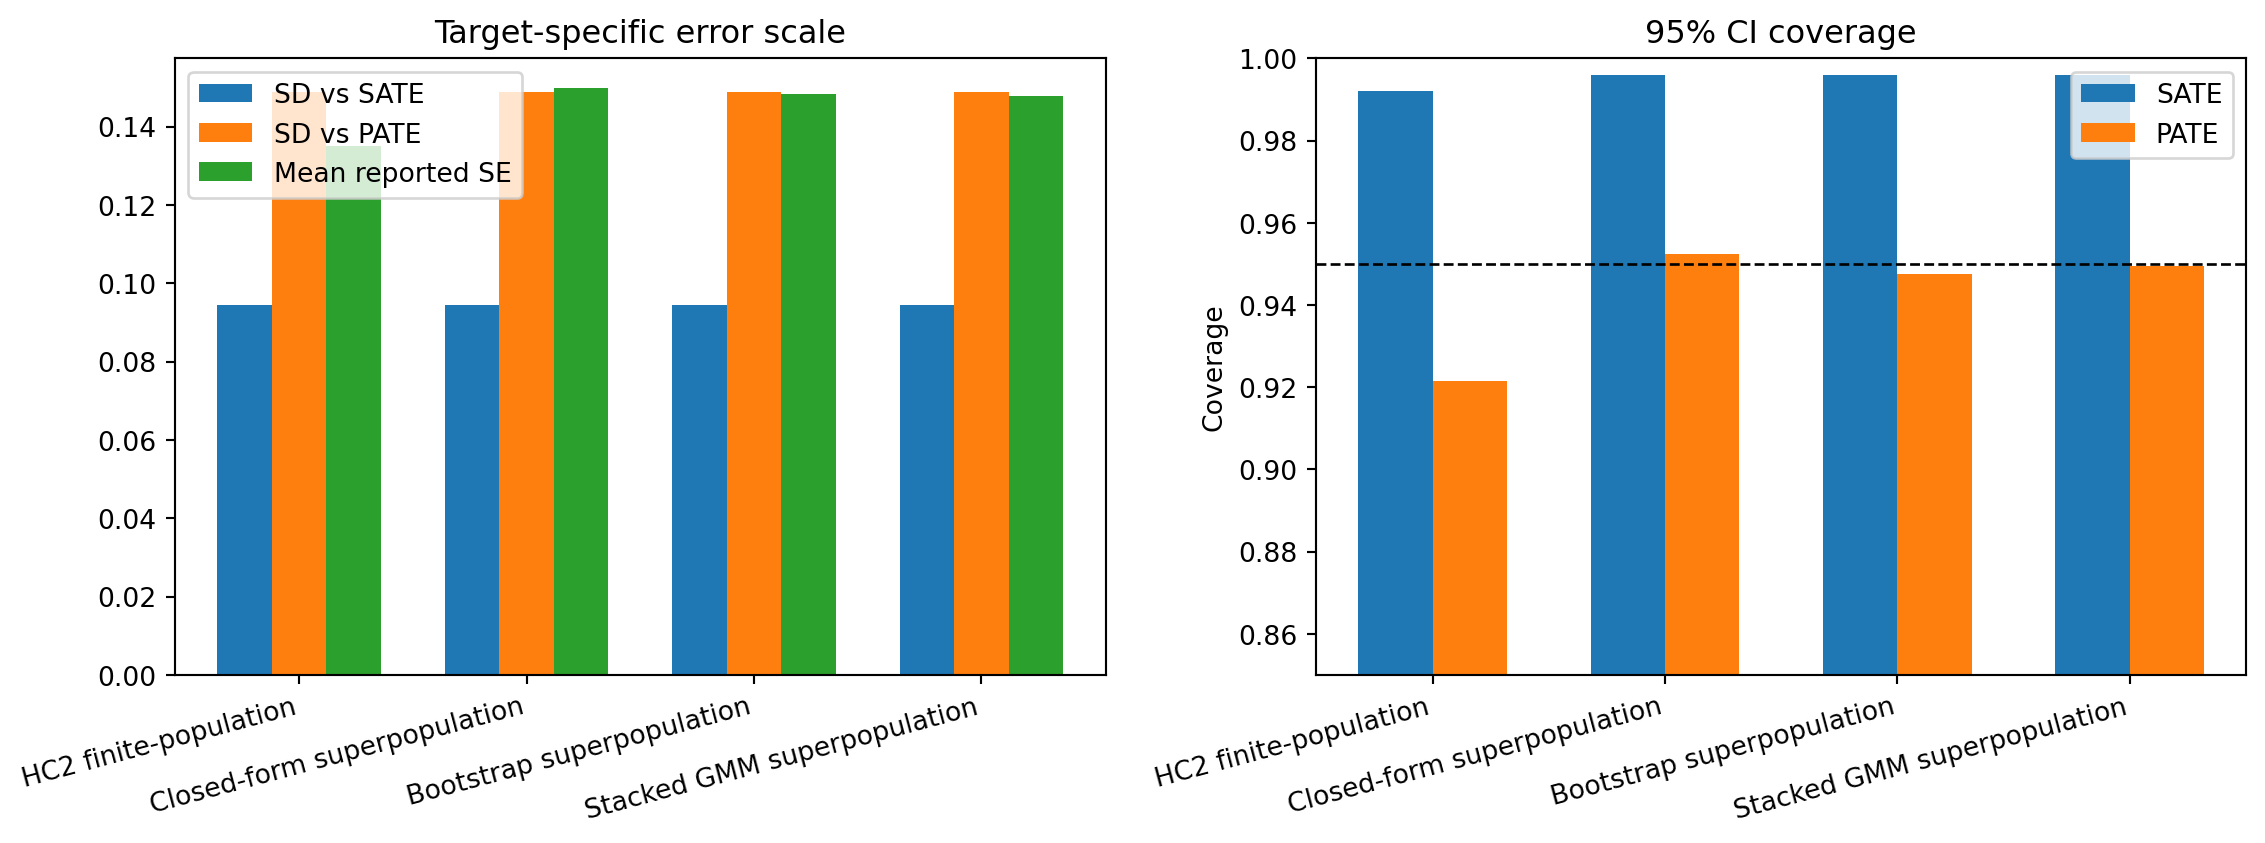

In [6]:
methods = [entry["method"] for entry in results]
mean_ses = [entry["mean_se"] for entry in results]
sate_error_sds = [entry["sate_error_sd"] for entry in results]
pate_error_sds = [entry["pate_error_sd"] for entry in results]
coverages_sate = [entry["coverage_sate"] for entry in results]
coverages_pate = [entry["coverage_pate"] for entry in results]
xpos = np.arange(len(methods))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].bar(xpos - 0.24, sate_error_sds, width=0.24, label="SD vs SATE")
axes[0].bar(xpos, pate_error_sds, width=0.24, label="SD vs PATE")
axes[0].bar(xpos + 0.24, mean_ses, width=0.24, label="Mean reported SE")
axes[0].set_xticks(xpos)
axes[0].set_xticklabels(methods, rotation=15, ha="right")
axes[0].set_title("Target-specific error scale")
axes[0].legend()

axes[1].bar(xpos - 0.16, coverages_sate, width=0.32, label="SATE")
axes[1].bar(xpos + 0.16, coverages_pate, width=0.32, label="PATE")
axes[1].axhline(0.95, color="black", linestyle="--", linewidth=1.0)
axes[1].set_ylim(0.85, 1.0)
axes[1].set_xticks(xpos)
axes[1].set_xticklabels(methods, rotation=15, ha="right")
axes[1].set_title("95% CI coverage")
axes[1].set_ylabel("Coverage")
axes[1].legend()

plt.tight_layout()
plt.show()